# 01. Exploratory Data Analysis (EDA) - NinaPro DB1

**Objective**: Understand signal dimensions, class imbalance, and gesture distribution for Subject 1.

In [2]:
# Force Jupyter to reload external modules automatically
%load_ext autoreload
%autoreload 2

import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure the notebook can find the src folder
sys.path.append(os.path.abspath('../'))
from src.utils import load_ninapro_mat, extract_zip

### 1. Load Subject 1 Data (All Exercises)
* Modify the `base_path` if your unzipped DB1 files are located elsewhere.
* Automatically extracts data from the ZIP file and reloads source modules.

In [3]:
db_dir = "../data/raw/Ninapro_DB1"
zip_path = os.path.join(db_dir, "s1.zip")
extract_dir = os.path.join(db_dir, "s1")

# Check if we need to unzip
if not os.path.exists(extract_dir) or len(os.listdir(extract_dir)) == 0:
    extract_zip(zip_path, extract_dir)

exercises = ['E1', 'E2', 'E3']
emg_list, labels_list, reps_list = [], [], []

for ex in exercises:
    # Some extractions place files directly in extract_dir, others nest them
    mat_path = os.path.join(extract_dir, f"S1_A1_{ex}.mat")
    if not os.path.exists(mat_path):
        mat_path = os.path.join(extract_dir, "s1", f"S1_A1_{ex}.mat")
        
    print(f"Loading {mat_path}...")
    
    data = load_ninapro_mat(mat_path)
    emg_list.append(data['emg'])
    labels_list.append(data['labels'])
    reps_list.append(data['reps'])

# Concatenate all exercises into continuous arrays for global analysis
emg_full = np.vstack(emg_list)
labels_full = np.concatenate(labels_list)
reps_full = np.concatenate(reps_list)

print("\n--- Global Subject 1 Statistics ---")
print(f"Total EMG Shape: {emg_full.shape} (Samples x Channels)")
print(f"Total Labels Shape: {labels_full.shape}")
print(f"Total Duration: {emg_full.shape[0] / 100.0 / 60.0:.2f} minutes (at 100 Hz)")

Extracting ../data/raw/Ninapro_DB1/s1.zip to ../data/raw/Ninapro_DB1/s1...
Loading ../data/raw/Ninapro_DB1/s1/S1_A1_E1.mat...
Loading ../data/raw/Ninapro_DB1/s1/S1_A1_E2.mat...
Loading ../data/raw/Ninapro_DB1/s1/S1_A1_E3.mat...

--- Global Subject 1 Statistics ---
Total EMG Shape: (471483, 10) (Samples x Channels)
Total Labels Shape: (471483,)
Total Duration: 78.58 minutes (at 100 Hz)


### 2. Class Distribution & The "Rest" Dilemma
Analyzing the class imbalance caused by the resting periods between gestures.

Rest Samples (Class 0): 289965 (61.50%)
Active Samples (Classes 1-52): 181518 (38.50%)


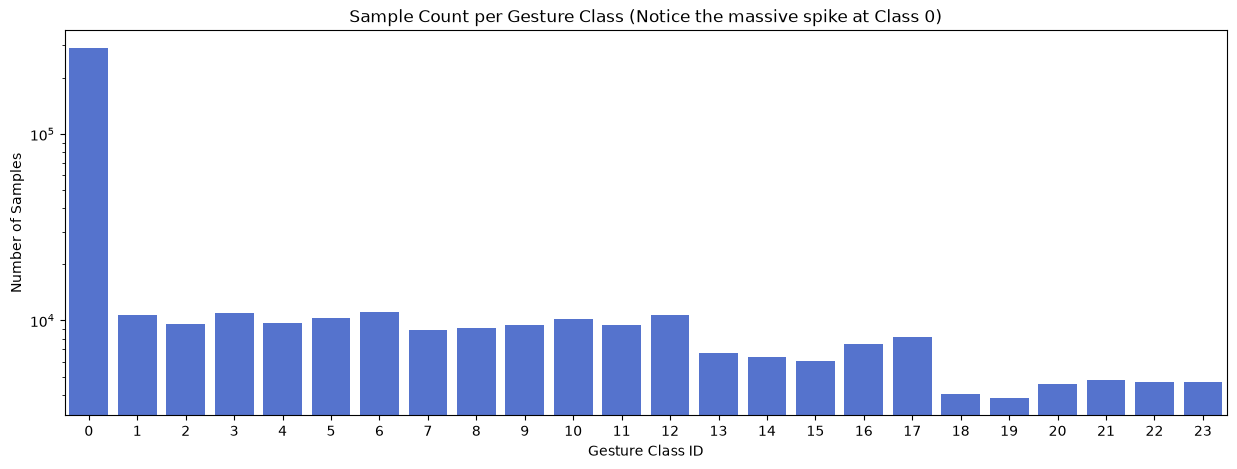

In [4]:
unique_classes, class_counts = np.unique(labels_full, return_counts=True)
rest_count = class_counts[0]
active_count = np.sum(class_counts[1:])

print(f"Rest Samples (Class 0): {rest_count} ({(rest_count/len(labels_full))*100:.2f}%)")
print(f"Active Samples (Classes 1-52): {active_count} ({(active_count/len(labels_full))*100:.2f}%)")

plt.figure(figsize=(15, 5))
sns.barplot(x=unique_classes, y=class_counts, color='royalblue')
plt.title("Sample Count per Gesture Class (Notice the massive spike at Class 0)")
plt.xlabel("Gesture Class ID")
plt.ylabel("Number of Samples")
plt.yscale('log') # Using log scale so active classes are visible next to rest
plt.show()

### 3. Visualizing a Single Gesture Iteration
Isolating Gesture 1, Repetition 1 to inspect the raw waveform and channel activation.

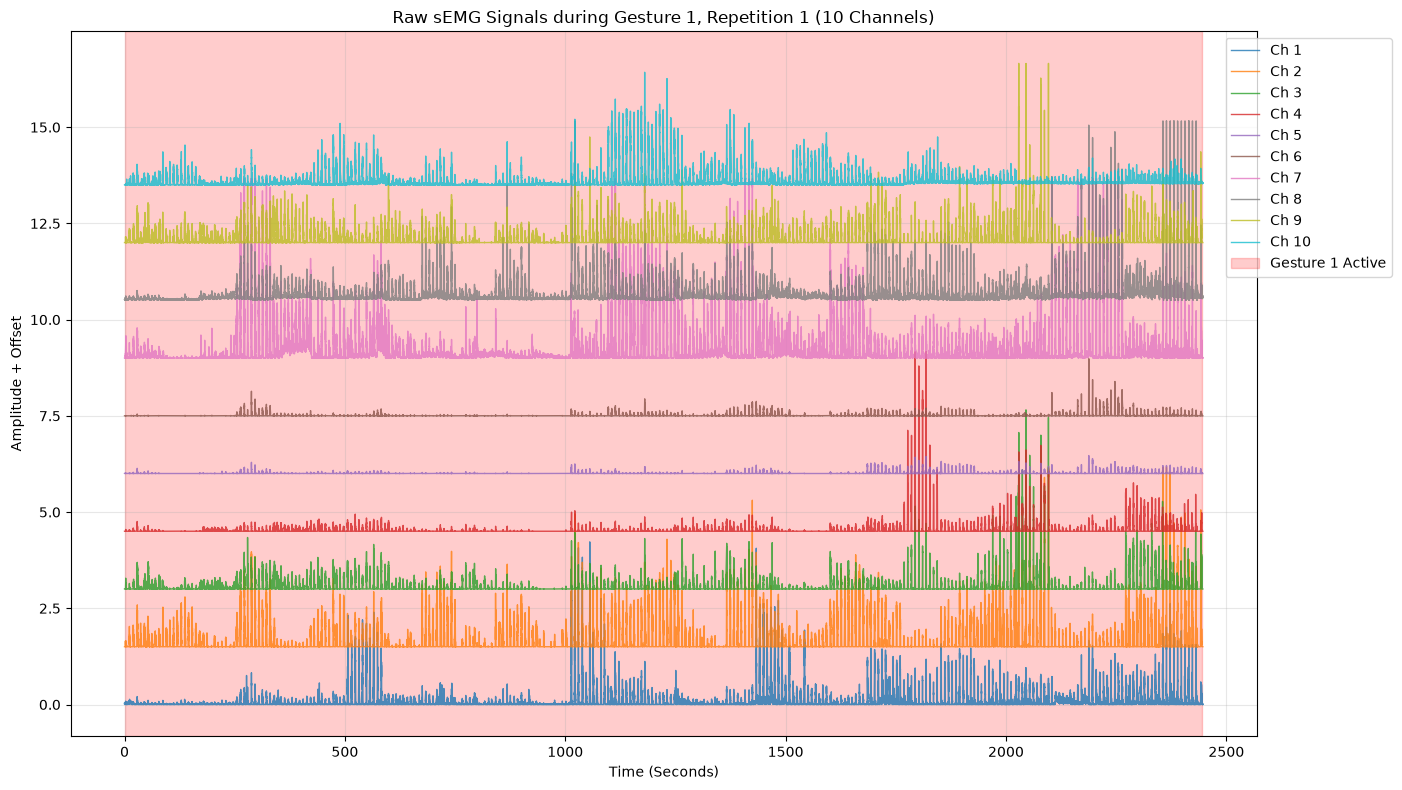

In [5]:
# Create a mask to isolate Gesture 1, Repetition 1
mask = (labels_full == 1) & (reps_full == 1)
indices = np.where(mask)[0]

if len(indices) > 0:
    start_idx = indices[0]
    end_idx = indices[-1]
    
    # Expand the window slightly to see the rest before and after the movement
    buffer = 200 # 2 seconds at 100Hz
    plot_start = max(0, start_idx - buffer)
    plot_end = min(len(labels_full), end_idx + buffer)
    
    time_axis = np.arange(plot_end - plot_start) / 100.0 # Convert to seconds
    
    plt.figure(figsize=(14, 8))
    for channel in range(10):
        # Add an offset to stack the signals visually
        offset = channel * 1.5 
        plt.plot(time_axis, emg_full[plot_start:plot_end, channel] + offset, 
                 label=f'Ch {channel+1}', alpha=0.8, linewidth=1)
    
    # Highlight the actual gesture execution time
    plt.axvspan((start_idx - plot_start)/100.0, (end_idx - plot_start)/100.0, 
                color='red', alpha=0.2, label='Gesture 1 Active')
                
    plt.title("Raw sEMG Signals during Gesture 1, Repetition 1 (10 Channels)")
    plt.xlabel("Time (Seconds)")
    plt.ylabel("Amplitude + Offset")
    plt.legend(loc='upper right', bbox_to_anchor=(1.12, 1))
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("Could not find Gesture 1, Repetition 1.")

**Observation:** The maximum class is 23. However, the NinaPro DB1 protocol explicitly states there are **52 distinct active movements**! 
 
**The Problem:** The raw `.mat` files reset their internal class counters for each exercise. E1 contains movements 1-12, E2 contains 1-17, and E3 contains 1-23. By directly concatenating them, we merged completely different physiological gestures (e.g., a finger flexion in E1 and a wrist rotation in E2) into the same class label.

### 4: The Robust Loading Approach (Correcting the Labels)
To fix the label overlap trap, we must apply a constant offset to the active gestures in Exercises 2 and 3.
Let $y_{raw}$ be the original label. For E2, the true label is $y_{true} = y_{raw} + 12$. For E3, it is $y_{true} = y_{raw} + 29$.

In [6]:
emg_list, labels_list, reps_list = [], [], []

# Defined by the NinaPro DB1 physiological protocol
offsets = {'E1': 0, 'E2': 12, 'E3': 29} 

for ex in exercises:
    mat_path = os.path.join(extract_dir, f"S1_A1_{ex}.mat")
    if not os.path.exists(mat_path):
        mat_path = os.path.join(extract_dir, "s1", f"S1_A1_{ex}.mat")
        
    print(f"Loading and correcting {mat_path}...")
    data = load_ninapro_mat(mat_path)
    
    # Apply continuous offsets to active classes (ignoring Rest class 0)
    labels = data['labels'].copy()
    active_mask = labels > 0
    labels[active_mask] += offsets[ex]
    
    emg_list.append(data['emg'])
    labels_list.append(labels)
    reps_list.append(data['reps'])

# Create the final, corrected global arrays
emg_full = np.vstack(emg_list)
labels_full = np.concatenate(labels_list)
reps_full = np.concatenate(reps_list)

print("\n--- Corrected Global Subject 1 Statistics ---")
print(f"Total EMG Shape: {emg_full.shape} (Samples x Channels)")
print(f"Total Labels Shape: {labels_full.shape}")
print(f"Max gesture class is now: {np.max(labels_full)}")
print(f"Total Duration: {emg_full.shape[0] / 100.0 / 60.0:.2f} minutes (at 100 Hz)")

Loading and correcting ../data/raw/Ninapro_DB1/s1/S1_A1_E1.mat...
Loading and correcting ../data/raw/Ninapro_DB1/s1/S1_A1_E2.mat...
Loading and correcting ../data/raw/Ninapro_DB1/s1/S1_A1_E3.mat...

--- Corrected Global Subject 1 Statistics ---
Total EMG Shape: (471483, 10) (Samples x Channels)
Total Labels Shape: (471483,)
Max gesture class is now: 52
Total Duration: 78.58 minutes (at 100 Hz)


### 5: Class Distribution and The "Rest" Dilemma
To prevent muscle fatigue, the subject rests for 3 seconds between every 5-second active gesture. Let's quantify how heavily this biases the dataset toward the Rest class (Class 0).

Rest Samples (Class 0): 289965 (61.50%)
Active Samples (Classes 1-52): 181518 (38.50%)


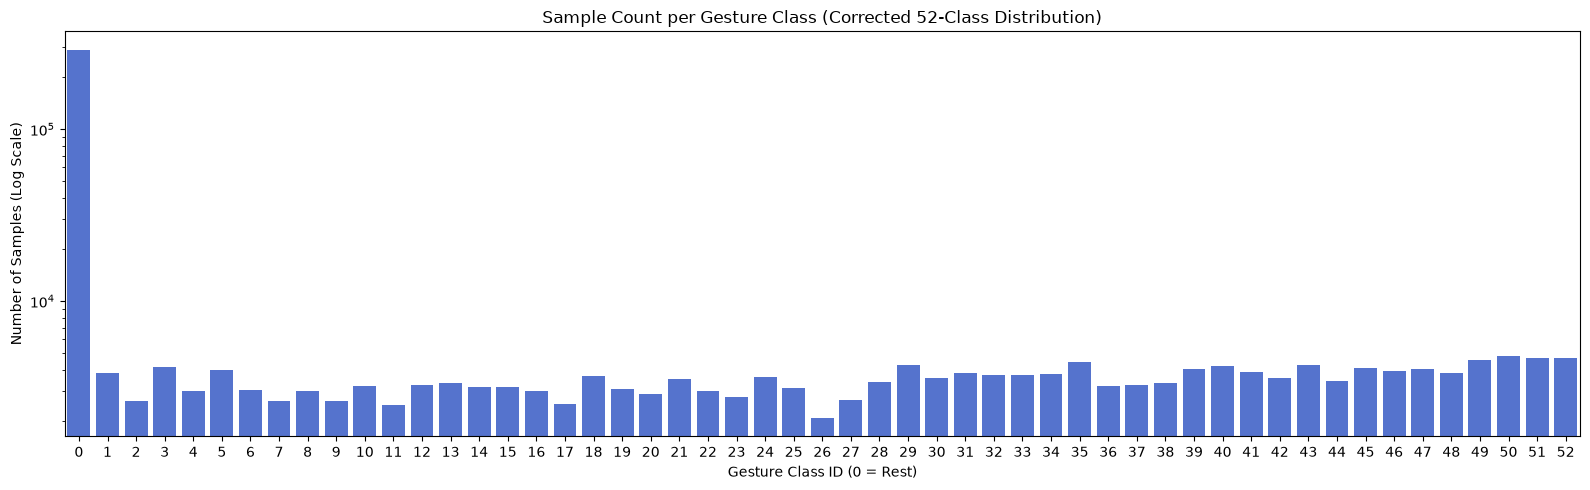

In [7]:
unique_classes, class_counts = np.unique(labels_full, return_counts=True)
rest_count = class_counts[0]
active_count = np.sum(class_counts[1:])

print(f"Rest Samples (Class 0): {rest_count} ({(rest_count/len(labels_full))*100:.2f}%)")
print(f"Active Samples (Classes 1-52): {active_count} ({(active_count/len(labels_full))*100:.2f}%)")

plt.figure(figsize=(16, 5))
sns.barplot(x=unique_classes, y=class_counts, color='royalblue')
plt.title("Sample Count per Gesture Class (Corrected 52-Class Distribution)")
plt.xlabel("Gesture Class ID (0 = Rest)")
plt.ylabel("Number of Samples (Log Scale)")
plt.yscale('log')
plt.tight_layout()
plt.show()

**Observation:** ~61.5% of the dataset is Class 0. If we do not address this, our future models (SVM, CNN) will overfit and constantly predict "Rest" to artificially inflate accuracy. We will handle this via undersampling in our preprocessing pipeline.

### 6: Visualizing a Single Gesture (Avoiding the Time-Spanning Trap)
If we simply search for `labels == 1` and `reps == 1`, we might accidentally capture indices from the very beginning of the dataset and the very end (due to naive concatenation bugs). 
 
To safely plot a single gesture, we must identify the **first contiguous block** of indices.

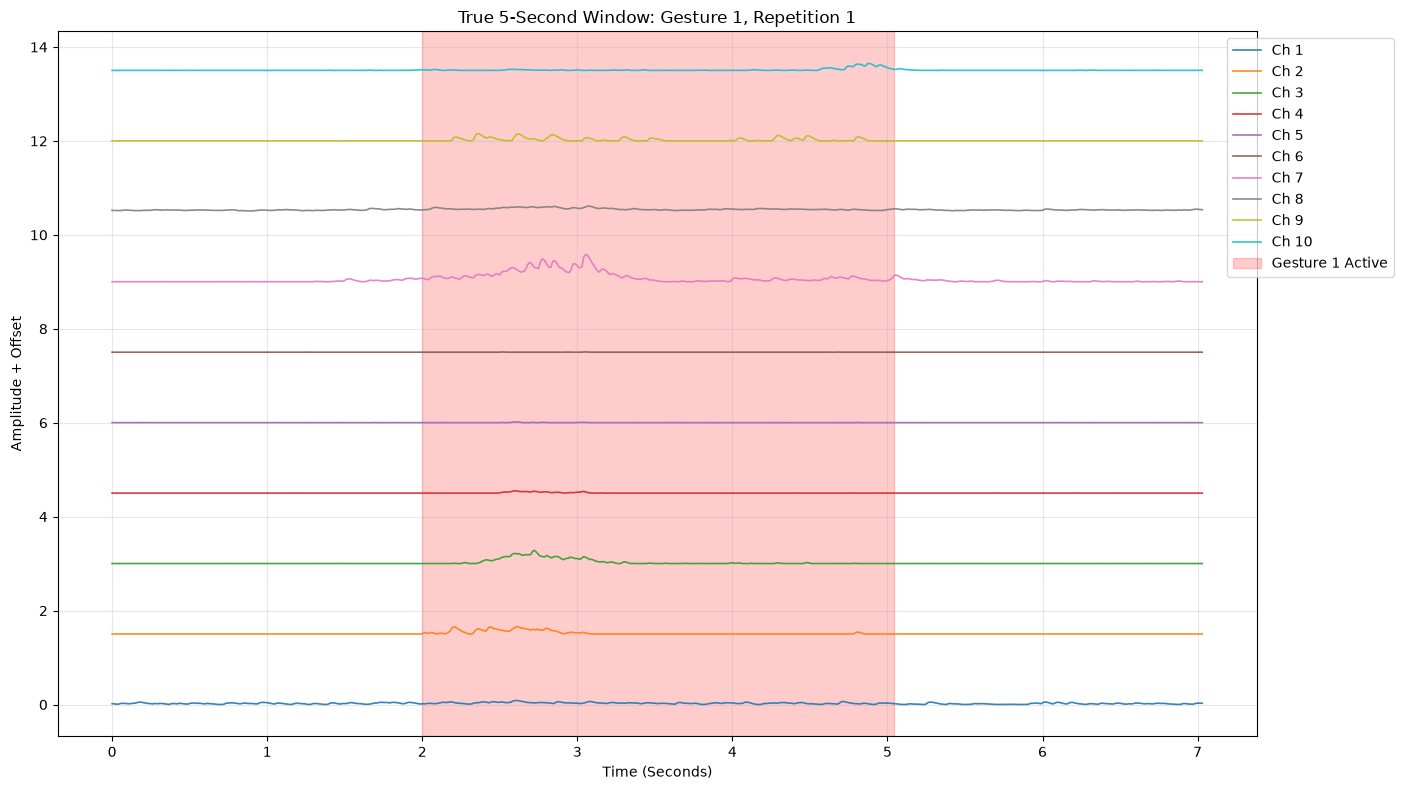

In [8]:
# Create a mask to isolate Gesture 1, Repetition 1
mask = (labels_full == 1) & (reps_full == 1)
indices = np.where(mask)[0]

if len(indices) > 0:
    # Find where the gap between consecutive indices is > 1
    # This isolates a single continuous execution block
    breaks = np.where(np.diff(indices) > 1)[0]
    if len(breaks) > 0:
        end_idx = indices[breaks[0]]
    else:
        end_idx = indices[-1]
        
    start_idx = indices[0]
    
    # Expand the window slightly to observe the Rest -> Active transition
    buffer = 200 # 2 seconds at 100Hz
    plot_start = max(0, start_idx - buffer)
    plot_end = min(len(labels_full), end_idx + buffer)
    
    time_axis = np.arange(plot_end - plot_start) / 100.0 
    
    plt.figure(figsize=(14, 8))
    for channel in range(10):
        # Apply a vertical offset to stack the signals
        offset = channel * 1.5 
        plt.plot(time_axis, emg_full[plot_start:plot_end, channel] + offset, 
                 label=f'Ch {channel+1}', alpha=0.9, linewidth=1.2)
    
    # Shade the active movement period
    plt.axvspan((start_idx - plot_start)/100.0, (end_idx - plot_start)/100.0, 
                color='red', alpha=0.2, label='Gesture 1 Active')
                
    plt.title("True 5-Second Window: Gesture 1, Repetition 1")
    plt.xlabel("Time (Seconds)")
    plt.ylabel("Amplitude + Offset")
    plt.legend(loc='upper right', bbox_to_anchor=(1.12, 1))
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("Could not find Gesture 1, Repetition 1.")